# Вопрос 2: Влияние ключевой ставки на рынок вкладов физлиц

## Метод
Local Projections (Jordà 2005) с лаг-аугментацией (Montiel Olea & Plagborg-Møller 2021).

## Гипотеза
Повышение ключевой ставки увеличивает объём срочных депозитов физлиц через механизм перекладывания: люди переносят деньги с текущих счетов на срочные вклады по мере роста депозитных ставок. Эффект нарастает постепенно и достигает максимума через 8–11 месяцев.

## Данные
- **Период:** сентябрь 2013 — декабрь 2025, помесячно
- **Зависимые переменные:** `total_funds_of_ind`, `time_deposits_of_ind`, `curr_accounts_of_ind`
- **Медиаторы:** `short_term_deposit_rate`, `long_term_deposit_rate` — показывают механизм передачи ставки в депозитные ставки; в основную модель не включаются чтобы не блокировать измеряемый эффект
- **Контроли:** `month` (сезонность), `shock_2014`, `shock_2022`
- **Лаг-аугментация:** `key_rate_lag1`, `y_lag1`, `trend` — для борьбы с персистентностью рядов

## Три спецификации
- **Наивная:** без лагов, без тренда
- **Финальная:** лаги + тренд

M2 — некорректный контроль для вопроса 2: `total_funds_of_ind` является компонентом М2, поэтому включение М2 в модель означает регрессию части на целое. Подходящий помесячный прокси экономического цикла недоступен — реальный ВВП и промышленное производство публикуются поквартально. Отсутствие контроля за экономическим циклом является ограничением модели.

In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

## 1. Загрузка данных

Загружаем итоговый датафрейм собранный в `preprocessing.ipynb`.

In [3]:
df_general = pd.read_csv('../data/general.csv', dtype={'date_formated': str})
df_general.head()

,Unnamed: 0,date_formated,key_rate,inflation,mortgage_count,mortgage_volume,seasoned_debts,mortgage_rate,short_term_deposit_rate,long_term_deposit_rate,m2,total_funds_of_ind,time_deposits_of_ind,curr_accounts_of_ind,month,shock_2014,subsidized_mortgage,shock_2022
0,0,9.2013,5.5,6.14,NaN,NaN,2279620.0,NaN,NaN,NaN,28499.9,15945.652852,13515.366534,2430.286318,9,0,0,0
1,1,10.2013,5.5,6.27,NaN,NaN,2284117.0,NaN,NaN,NaN,28352.6,15945.713302,13556.636282,2389.077020,10,0,0,0
2,2,11.2013,5.5,6.50,NaN,NaN,2360275.0,NaN,NaN,NaN,28276.4,16062.065195,13706.670941,2355.394254,11,0,0,0
3,3,12.2013,5.5,6.47,NaN,NaN,2428127.0,NaN,NaN,NaN,28873.3,16260.794307,13832.959743,2427.834564,12,0,0,0
4,4,1.2014,5.5,6.07,NaN,NaN,2498806.0,NaN,NaN,NaN,31155.6,16957.531046,14034.007723,2923.523323,1,0,0,0


## 2. Подготовка датафрейма для вопроса 2

- Период определяется доступностью `total_funds_of_ind` — с сентября 2013
- Методологический разрыв в данных по вкладам после января 2024 устранён в preprocessing: из строки «Физические лица» вычтены начисленные проценты
- Нет необходимости исключать периоды субсидий — вклады физлиц не затронуты программами льготной ипотеки

In [4]:
df_q2 = df_general[df_general['total_funds_of_ind'].notna()].copy()

print(f"Наблюдений: {len(df_q2)}")
print(f"Период: {df_q2['date_formated'].iloc[0]} — {df_q2['date_formated'].iloc[-1]}")

Наблюдений: 156
Период: 9.2013 — 8.2026


## 3. Диагностика персистентности и стационарности

Проверяем ADF для `key_rate`, `total_funds_of_ind`, `m2`.
Если единичный корень не отвергается — нужна лаг-аугментация и/или тренд.
Аналогично вопросу 1: без этого шага LP даёт ложную значимость из-за персистентности рядов.

In [5]:
print('ADF тест')
for col in ['key_rate', 'total_funds_of_ind']:
    series = df_general[col].dropna()
    res_trend = adfuller(series, regression='ct', autolag='AIC')
    res_const = adfuller(series, regression='c', autolag='AIC')
    print(f"{col} (trend): ADF={res_trend[0]:.3f}, p={res_trend[1]:.3f}")
    print(f"{col} (const): ADF={res_const[0]:.3f}, p={res_const[1]:.3f}")

ADF тест
key_rate (trend): ADF=-2.623, p=0.269
key_rate (const): ADF=-2.351, p=0.156
total_funds_of_ind (trend): ADF=-3.863, p=0.014
total_funds_of_ind (const): ADF=-0.954, p=0.770


/var/folders/q2/kfw_zqsj0vngl1pfqbp5mhmr0000gn/T/ipykernel_94717/1591069250.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_trend = adfuller(series, regression='ct', autolag='AIC')
/var/folders/q2/kfw_zqsj0vngl1pfqbp5mhmr0000gn/T/ipykernel_94717/1591069250.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_const = adfuller(series, regression='c', autolag='AIC

### Результаты ADF-теста

| Переменная | ADF (trend) | p | ADF (const) | p | Единичный корень | Итоговое решение |
|---|---|---|---|---|---|---|
| `key_rate` | −2.623 | 0.269 | −2.351 | 0.156 | **не отвергается** (оба варианта) | Лаг-аугментация (`key_rate_lag1`). Тренд не нужен — у ставки его нет. |
| `total_funds_of_ind` | −3.863 | **0.014** | −0.954 | 0.770 | отвергается с трендом, не отвергается без | Добавить `trend` в контролы + лаг-аугментация (`y_lag1`). |

## 4. Оценка персистентности через AR(1)

p — коэффициент при лаге. Если p > 0.95 — высокая персистентность, нужна лаг-аугментация.

In [6]:
print('Авторегрессия 1 порядка')
for col in ['key_rate', 'total_funds_of_ind']:
    df_tmp = df_general[[col]].dropna().copy()
    df_tmp['lag'] = df_tmp[col].shift(1)
    df_tmp = df_tmp.dropna()
    model = sm.OLS(df_tmp[col], sm.add_constant(df_tmp['lag'])).fit()
    print(f"{col}: rho = {model.params['lag']:.4f}, p = {model.pvalues['lag']:.4f}")

Авторегрессия 1 порядка
key_rate: rho = 0.9553, p = 0.0000
total_funds_of_ind: rho = 1.0133, p = 0.0000


### Результаты AR(1)

| Переменная | ρ | p (ρ = 0) | Интерпретация | Итоговое решение |
|---|---|---|---|---|
| `key_rate` | 0.9553 | 0.0000 | высокая персистентность, «почти единичный корень» | Лаг-аугментация: добавить `key_rate_lag1` в регрессию. |
| `total_funds_of_ind` | 1.0133 | 0.0000 | p > 1 — артефакт детерминированного тренда | Добавить `trend` в контролы + `y_lag1` для лаг-аугментации. |

**Примечание:** p в AR(1) проверяет гипотезу p = 0, а не p = 1. Малое p здесь означает что ρ значимо отличается от нуля, что свойственно персистентным рядам. Для проверки p = 1 нужен ADF.

## 5. Добавление вспомогательных переменных

- `trend` — линейный тренд, компенсирует нестационарность `total_funds_of_ind`
- `key_rate_lag1` — лаг ключевой ставки, лаг-аугментация для борьбы с персистентностью
- `y_lag1` — лаг зависимой переменной, добавляется внутри функции `run_three_specs`

In [7]:
df_q2['trend'] = range(1, df_q2.shape[0] + 1)
df_q2['key_rate_lag1'] = df_q2['key_rate'].shift(1)

## 6. Вспомогательные функции для LP

`print_lp_results` — выводит коэффициенты, p-value и доверительные интервалы по горизонтам.

`run_three_specs` — запускает три спецификации для одной зависимой переменной:
- **naive:** контроли без лагов и тренда
- **final:** с `key_rate_lag1`, `y_lag1`, `trend`

In [8]:
def print_lp_results(results, title, max_h=15):
    print(f"\n{title}")
    print("-" * 60)
    for h in range(0, max_h + 1):
        if h not in results:
            continue
        coef = results[h].params['key_rate']
        pval = results[h].pvalues['key_rate']
        ci_low = results[h].conf_int().loc['key_rate', 0]
        ci_high = results[h].conf_int().loc['key_rate', 1]
        sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        print(f"h={h:2d}: коэф={coef:8.1f}, p={pval:.3f} {sig:3s}, CI=[{ci_low:8.1f}, {ci_high:8.1f}]")

In [9]:
def run_three_specs(df, y_col, max_h=15):
    df_work = df.copy()
    df_work['y_lag1'] = df_work[y_col].shift(1)
    
    controls_naive = ['month', 'shock_2014', 'shock_2022']
    controls_final = ['month', 'shock_2014', 'shock_2022',
                      'key_rate_lag1', 'y_lag1']
    if y_col not in ('short_term_deposit_rate', 'long_term_deposit_rate'):
        controls_final.append('trend')
    
    specs = {
        'naive': controls_naive,
        'final': controls_final,
    }

    all_results = {}
    for spec_name, controls in specs.items():
        results = {}
        for h in range(0, max_h + 1):
            df_work[f'y_h{h}'] = df_work[y_col].shift(-h)
            df_model = df_work[['key_rate'] + controls + [f'y_h{h}']].dropna()
            
            X = sm.add_constant(df_model[['key_rate'] + controls])
            y = df_model[f'y_h{h}']
            results[h] = sm.OLS(y, X).fit(cov_type='HC3')
        all_results[spec_name] = results
    
    return all_results

## 7. Модель 1: Общий объём вкладов физлиц

Зависимая переменная: `total_funds_of_ind`

Контроли: `month`, `shock_2014`, `shock_2022`, `key_rate_lag1`, `y_lag1`, `trend`

In [10]:
specs_total = run_three_specs(df_q2, 'total_funds_of_ind', max_h=15)

print_lp_results(specs_total['naive'], 
                 "НАИВНАЯ: без лагов", max_h=15)

print_lp_results(specs_total['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд", max_h=15)


НАИВНАЯ: без лагов
------------------------------------------------------------
h= 0: коэф=  2167.9, p=0.000 ***, CI=[  1859.6,   2476.1]
h= 1: коэф=  2186.9, p=0.000 ***, CI=[  1880.5,   2493.2]
h= 2: коэф=  2205.6, p=0.000 ***, CI=[  1901.9,   2509.3]
h= 3: коэф=  2219.7, p=0.000 ***, CI=[  1917.7,   2521.8]
h= 4: коэф=  2228.9, p=0.000 ***, CI=[  1926.6,   2531.1]
h= 5: коэф=  2241.6, p=0.000 ***, CI=[  1940.0,   2543.1]
h= 6: коэф=  2245.1, p=0.000 ***, CI=[  1943.5,   2546.6]
h= 7: коэф=  2245.1, p=0.000 ***, CI=[  1943.1,   2547.1]
h= 8: коэф=  2236.4, p=0.000 ***, CI=[  1931.8,   2541.0]
h= 9: коэф=  2237.5, p=0.000 ***, CI=[  1934.4,   2540.6]
h=10: коэф=  2229.1, p=0.000 ***, CI=[  1923.9,   2534.3]
h=11: коэф=  2218.3, p=0.000 ***, CI=[  1912.3,   2524.4]
h=12: коэф=  2201.7, p=0.000 ***, CI=[  1893.2,   2510.1]
h=13: коэф=  2192.3, p=0.000 ***, CI=[  1878.5,   2506.2]
h=14: коэф=  2174.3, p=0.000 ***, CI=[  1853.7,   2495.0]
h=15: коэф=  2163.1, p=0.000 ***, CI=[  1828.5,  

### Вывод по модели 1: общий объём вкладов

- **Наивная модель** даёт p = 0.000 на всех горизонтах с коэффициентами ~2200 млрд руб. — очевидная ложная значимость из-за персистентности: `total_funds_of_ind` растёт трендово и `key_rate` персистентна, модель без лагов и тренда просто фиксирует совместный рост.
- **Финальная модель** (с лагами и трендом) даёт значимость на h=6–7 (p=0.009 и 0.006) и h=11–12 (p=0.011 и 0.047). На остальных горизонтах незначимо, коэффициенты положительные но CI включают ноль.
- Коэффициенты в финальной модели на порядок меньше наивной (300–500 млрд vs 2200 млрд) — лаг-аугментация убрала большую часть ложной связи.

**Вывод:** эффект есть но неустойчивый — значимость появляется только на средних (h=6–7) и длинных (h=11–15) горизонтах. Для содержательного вывода смотрим модель 2 (срочные депозиты) — там сигнал чище.

## 8. Модель 2: Срочные депозиты физлиц

Зависимая переменная: `time_deposits_of_ind`

In [11]:
specs_td = run_three_specs(df_q2, 'time_deposits_of_ind', max_h=15)

print_lp_results(specs_td['naive'], 
                 "НАИВНАЯ: без лагов", max_h=15)

print_lp_results(specs_td['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд", max_h=15)


НАИВНАЯ: без лагов
------------------------------------------------------------
h= 0: коэф=  1459.0, p=0.000 ***, CI=[  1250.9,   1667.2]
h= 1: коэф=  1497.2, p=0.000 ***, CI=[  1296.3,   1698.1]
h= 2: коэф=  1537.3, p=0.000 ***, CI=[  1345.3,   1729.3]
h= 3: коэф=  1563.6, p=0.000 ***, CI=[  1376.7,   1750.6]
h= 4: коэф=  1584.1, p=0.000 ***, CI=[  1401.3,   1766.9]
h= 5: коэф=  1602.9, p=0.000 ***, CI=[  1424.6,   1781.2]
h= 6: коэф=  1615.5, p=0.000 ***, CI=[  1439.9,   1791.1]
h= 7: коэф=  1623.1, p=0.000 ***, CI=[  1449.5,   1796.6]
h= 8: коэф=  1627.0, p=0.000 ***, CI=[  1455.2,   1798.8]
h= 9: коэф=  1633.7, p=0.000 ***, CI=[  1464.2,   1803.3]
h=10: коэф=  1634.4, p=0.000 ***, CI=[  1466.6,   1802.3]
h=11: коэф=  1632.4, p=0.000 ***, CI=[  1466.4,   1798.5]
h=12: коэф=  1627.0, p=0.000 ***, CI=[  1460.7,   1793.3]
h=13: коэф=  1624.8, p=0.000 ***, CI=[  1455.8,   1793.7]
h=14: коэф=  1618.4, p=0.000 ***, CI=[  1444.8,   1791.9]
h=15: коэф=  1615.7, p=0.000 ***, CI=[  1431.8,  

### Вывод по модели 2: срочные депозиты

- **Наивная модель** — ложная значимость везде, коэффициенты ~1600 млрд руб.
- **Финальная модель** даёт устойчивую значимость начиная с h=2 (p=0.001) и до h=15 (p=0.004). Коэффициенты нарастают монотонно: h=2 (около 330 млрд) → h=15 (около 942 млрд).
- На h=0 и h=1 незначимо — срочные депозиты не реагируют мгновенно, нужно время чтобы банки подняли ставки и люди перенесли деньги.

**Вывод:** это самый чистый результат во всём вопросе 2. Повышение ключевой ставки на 1 п.п. устойчиво увеличивает объём срочных депозитов начиная со второго месяца, эффект продолжает нарастать до h=15 без признаков затухания — люди продолжают открывать вклады пока ставки остаются высокими.

## 9. Модель 3: Текущие счета физлиц

Зависимая переменная: `curr_accounts_of_ind`

In [12]:
specs_ca = run_three_specs(df_q2, 'curr_accounts_of_ind', max_h=15)

print_lp_results(specs_ca['naive'], 
                 "НАИВНАЯ: без лагов, без тренда", max_h=15)

print_lp_results(specs_ca['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд", max_h=15)


НАИВНАЯ: без лагов, без тренда
------------------------------------------------------------
h= 0: коэф=   708.8, p=0.000 ***, CI=[   585.6,    832.0]
h= 1: коэф=   689.6, p=0.000 ***, CI=[   563.4,    815.8]
h= 2: коэф=   668.3, p=0.000 ***, CI=[   538.3,    798.3]
h= 3: коэф=   656.1, p=0.000 ***, CI=[   523.9,    788.3]
h= 4: коэф=   644.7, p=0.000 ***, CI=[   509.9,    779.5]
h= 5: коэф=   638.7, p=0.000 ***, CI=[   501.2,    776.1]
h= 6: коэф=   629.6, p=0.000 ***, CI=[   490.2,    768.9]
h= 7: коэф=   622.0, p=0.000 ***, CI=[   480.9,    763.1]
h= 8: коэф=   609.4, p=0.000 ***, CI=[   465.0,    753.7]
h= 9: коэф=   603.7, p=0.000 ***, CI=[   459.0,    748.5]
h=10: коэф=   594.6, p=0.000 ***, CI=[   447.4,    741.9]
h=11: коэф=   585.9, p=0.000 ***, CI=[   436.8,    735.0]
h=12: коэф=   574.7, p=0.000 ***, CI=[   423.5,    725.9]
h=13: коэф=   567.6, p=0.000 ***, CI=[   413.4,    721.7]
h=14: коэф=   556.0, p=0.000 ***, CI=[   398.1,    713.8]
h=15: коэф=   547.4, p=0.000 ***, CI=

### Вывод по модели 3: текущие счета

- **Наивная модель** — ложная значимость, коэффициенты положительные (~600 млрд) что противоречит ожидаемой логике.
- **Финальная модель** даёт отрицательные коэффициенты значимые на h=2–7 и h=9–10. Пик падения на h=4 (−255 млрд, p=0.003).
- На h=8, h=11–15 значимость пропадает — эффект перекладывания затухает на длинных горизонтах.

**Вывод:** механизм перекладывания подтверждён. При повышении ставки деньги уходят с текущих счетов на срочные депозиты — эффект значим со второго месяца и достигает максимума на четвёртом. Сравнивая с моделью 2: срочные депозиты растут (около 480 млрд на h=4), текущие падают (около 255 млрд на h=4) — разница (около 225 млрд) это приток новых денег в банковскую систему сверх перекладывания.

## 10. Модель 4: Краткосрочная ставка по вкладам (до 1 года)

Зависимая переменная: `short_term_deposit_rate`

Это **медиатор**: ставка ЦБ → ставка по вкладам → объём вкладов.

In [13]:
specs_short = run_three_specs(df_q2, 'short_term_deposit_rate', max_h=15)

print_lp_results(specs_short['naive'], 
                 "НАИВНАЯ: без лагов, без тренда", max_h=15)

print_lp_results(specs_short['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд", max_h=15)


НАИВНАЯ: без лагов, без тренда
------------------------------------------------------------
h= 0: коэф=     1.0, p=0.000 ***, CI=[     0.9,      1.0]
h= 1: коэф=     1.0, p=0.000 ***, CI=[     1.0,      1.1]
h= 2: коэф=     1.0, p=0.000 ***, CI=[     0.9,      1.0]
h= 3: коэф=     1.0, p=0.000 ***, CI=[     0.9,      1.0]
h= 4: коэф=     1.0, p=0.000 ***, CI=[     0.9,      1.0]
h= 5: коэф=     0.9, p=0.000 ***, CI=[     0.8,      1.0]
h= 6: коэф=     0.9, p=0.000 ***, CI=[     0.8,      1.0]
h= 7: коэф=     0.9, p=0.000 ***, CI=[     0.8,      1.0]
h= 8: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 9: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h=10: коэф=     0.8, p=0.000 ***, CI=[     0.6,      0.9]
h=11: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.9]
h=12: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h=13: коэф=     0.7, p=0.000 ***, CI=[     0.5,      0.8]
h=14: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.8]
h=15: коэф=     0.6, p=0.000 ***, CI=

### Вывод по модели 4: краткосрочная ставка по вкладам

- **Наивная модель** — почти полная передача (β ≈ 1.0) на всех горизонтах сразу, но это ложная значимость — оба ряда персистентны.
- **Финальная модель** даёт значимость только на h=2–3 (p=0.000) и h=5 (p=0.037). На h=0–1 и h=7+ незначимо с широкими CI.
- Коэффициент на h=2–3 около 0.9–1.1 п.п. — близко к полной передаче.

**Вывод:** краткосрочная ставка по вкладам реагирует на ключевую с лагом 2–3 месяца. Передача близка к полной (коэф около 1) но неустойчива на длинных горизонтах — CI становятся очень широкими после h=6. Это согласуется с логикой: банки быстро транслируют ставку в краткосрочные депозиты, но затем подстраиваются по мере изменения ожиданий.

## 11. Модель 5: Долгосрочная ставка по вкладам (1–3 года)

Зависимая переменная: `long_term_deposit_rate`

Для long_term_deposit_rate тренд не нужен. Долгосрочная ставка по вкладам не имеет детерминированного тренда — она колеблется вокруг какого-то уровня. Добавление trend «съедает» вариацию, которая на самом деле принадлежит ставке.

In [14]:
specs_long = run_three_specs(df_q2, 'long_term_deposit_rate', max_h=15)

print_lp_results(specs_long['naive'], 
                 "НАИВНАЯ: без лагов, без тренда", max_h=15)

print_lp_results(specs_long['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд", max_h=15)


НАИВНАЯ: без лагов, без тренда
------------------------------------------------------------
h= 0: коэф=     0.8, p=0.000 ***, CI=[     0.8,      0.9]
h= 1: коэф=     0.8, p=0.000 ***, CI=[     0.8,      0.9]
h= 2: коэф=     0.8, p=0.000 ***, CI=[     0.8,      0.9]
h= 3: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 4: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 5: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.8]
h= 6: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h= 7: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h= 8: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h= 9: коэф=     0.7, p=0.000 ***, CI=[     0.5,      0.8]
h=10: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.8]
h=11: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.7]
h=12: коэф=     0.6, p=0.000 ***, CI=[     0.4,      0.7]
h=13: коэф=     0.5, p=0.000 ***, CI=[     0.4,      0.7]
h=14: коэф=     0.5, p=0.000 ***, CI=[     0.4,      0.6]
h=15: коэф=     0.5, p=0.000 ***, CI=

### Вывод по модели 5: долгосрочная ставка по вкладам

- **Наивная модель** даёт коэф около 0.8 на h=0 с постепенным затуханием до 0.5 к h=15 — это правдоподобная оценка, ставка по вкладам не имеет трендового роста поэтому риск ложной регрессии здесь ниже чем для объёмов.
- **Финальная модель** даёт значимость на h=0–12 (p < 0.05) и пограничную на h=7, 13–15 (p = 0.057–0.086). Коэффициент нарастает от 0.1 на h=0 до 0.9 на h=9–12.
- Интересно что финальная модель даёт более низкие оценки на коротких горизонтах (коэф=0.1 на h=0) но выходит на тот же уровень около 0.9 на длинных — лаг-аугментация перераспределяет эффект во времени.

**Вывод:** долгосрочная ставка по вкладам реагирует на ключевую медленнее краткосрочной — полная передача (коэф около 0.9) достигается только к h=9, тогда как краткосрочная выходит на этот уровень уже к h=2–3. Это согласуется с экономической логикой: банки не торопятся фиксировать высокую ставку на длинный срок при неопределённости будущей денежно кредитной политики.

## 12. Подготовка данных для визуализации

Собираем коэффициенты и доверительные интервалы для каждого горизонта.

In [15]:
horizons = list(range(0, 16))

# Краткосрочная ставка
coefs_short = [specs_short['final'][h].params['key_rate'] for h in horizons]
ci_low_short = [specs_short['final'][h].conf_int().loc['key_rate', 0] for h in horizons]
ci_high_short = [specs_short['final'][h].conf_int().loc['key_rate', 1] for h in horizons]

# Долгосрочная ставка
coefs_long = [specs_long['final'][h].params['key_rate'] for h in horizons]
ci_low_long = [specs_long['final'][h].conf_int().loc['key_rate', 0] for h in horizons]
ci_high_long = [specs_long['final'][h].conf_int().loc['key_rate', 1] for h in horizons]

# Срочные депозиты
coefs_td = [specs_td['final'][h].params['key_rate'] for h in horizons]
ci_low_td = [specs_td['final'][h].conf_int().loc['key_rate', 0] for h in horizons]
ci_high_td = [specs_td['final'][h].conf_int().loc['key_rate', 1] for h in horizons]

# Текущие счета
coefs_ca = [specs_ca['final'][h].params['key_rate'] for h in horizons]
ci_low_ca = [specs_ca['final'][h].conf_int().loc['key_rate', 0] for h in horizons]
ci_high_ca = [specs_ca['final'][h].conf_int().loc['key_rate', 1] for h in horizons]

# Общий объём вкладов
coefs_total = [specs_total['final'][h].params['key_rate'] for h in horizons]
ci_low_total = [specs_total['final'][h].conf_int().loc['key_rate', 0] for h in horizons]
ci_high_total = [specs_total['final'][h].conf_int().loc['key_rate', 1] for h in horizons]
results_total = specs_total['final']

## 13. Визуализация механизма передачи

Три графика:
1. Передача ставки в ставки по вкладам (шаг 1)
2. Перекладывание средств (шаг 2)
3. Итоговый эффект на общий объём (шаг 3)

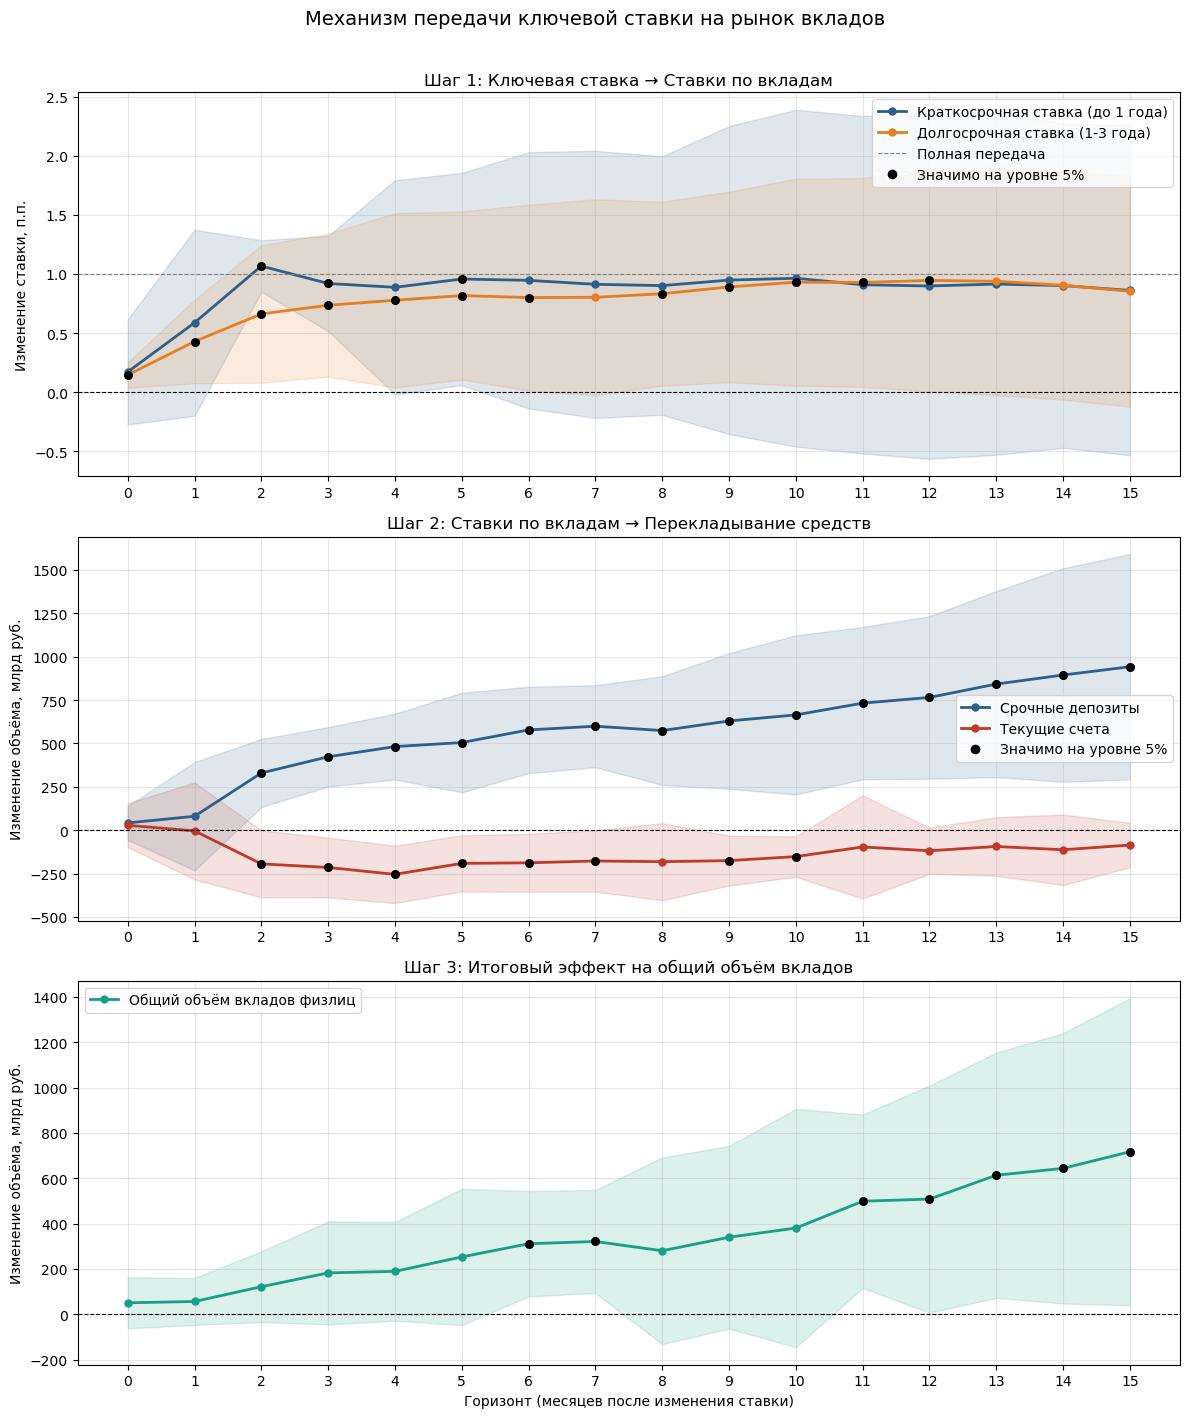

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Механизм передачи ключевой ставки на рынок вкладов', 
             fontsize=14, y=1.01)

# Передача в ставки по вкладам
ax1 = axes[0]
ax1.plot(horizons, coefs_short, color='#2c5f8a', linewidth=2,
         marker='o', markersize=5, label='Краткосрочная ставка (до 1 года)')
ax1.fill_between(horizons, ci_low_short, ci_high_short, alpha=0.15, color='#2c5f8a')
ax1.plot(horizons, coefs_long, color='#e67e22', linewidth=2,
         marker='o', markersize=5, label='Долгосрочная ставка (1-3 года)')
ax1.fill_between(horizons, ci_low_long, ci_high_long, alpha=0.15, color='#e67e22')
ax1.axhline(1, color='grey', linewidth=0.8, linestyle='--', label='Полная передача')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Шаг 1: Ключевая ставка → Ставки по вкладам')
ax1.set_ylabel('Изменение ставки, п.п.')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_xticks(horizons)

# Перекладывание средств
ax2 = axes[1]
ax2.plot(horizons, coefs_td, color='#2c5f8a', linewidth=2,
         marker='o', markersize=5, label='Срочные депозиты')
ax2.fill_between(horizons, ci_low_td, ci_high_td, alpha=0.15, color='#2c5f8a')
ax2.plot(horizons, coefs_ca, color='#c0392b', linewidth=2,
         marker='o', markersize=5, label='Текущие счета')
ax2.fill_between(horizons, ci_low_ca, ci_high_ca, alpha=0.15, color='#c0392b')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Шаг 2: Ставки по вкладам → Перекладывание средств')
ax2.set_ylabel('Изменение объёма, млрд руб.')
ax2.legend(loc='center right')
ax2.grid(alpha=0.3)
ax2.set_xticks(horizons)

# Итоговый эффект
ax3 = axes[2]
ax3.plot(horizons, coefs_total, color='#16a085', linewidth=2,
         marker='o', markersize=5, label='Общий объём вкладов физлиц')
ax3.fill_between(horizons, ci_low_total, ci_high_total, alpha=0.15, color='#16a085')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')

for h in horizons:
    if specs_short['final'][h].pvalues['key_rate'] < 0.05:
        ax1.scatter(h, coefs_short[h], color='black', zorder=5, s=30)
    if specs_long['final'][h].pvalues['key_rate'] < 0.05:
        ax1.scatter(h, coefs_long[h], color='black', zorder=5, s=30)

for h in horizons:
    if specs_td['final'][h].pvalues['key_rate'] < 0.05:
        ax2.scatter(h, coefs_td[h], color='black', zorder=5, s=30)
    if specs_ca['final'][h].pvalues['key_rate'] < 0.05:
        ax2.scatter(h, coefs_ca[h], color='black', zorder=5, s=30)

for h in horizons:
    if specs_total['final'][h].pvalues['key_rate'] < 0.05:
        ax3.scatter(h, coefs_total[h], color='black', zorder=5, s=30)

sig_marker = Line2D([0], [0], marker='o', color='w', 
                    markerfacecolor='black', markersize=8, 
                    label='Значимо на уровне 5%')

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles=handles1 + [sig_marker], loc='upper right')

handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles=handles2 + [sig_marker], loc='center right')

handles3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(handles=handles3 + [sig_marker], loc='upper left')

ax3.set_title('Шаг 3: Итоговый эффект на общий объём вкладов')
ax3.set_ylabel('Изменение объёма, млрд руб.')
ax3.set_xlabel('Горизонт (месяцев после изменения ставки)')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)
ax3.set_xticks(horizons)

plt.tight_layout()
plt.savefig('transmission_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по графику механизма передачи

**Шаг 1 (ставка → ставки по вкладам).** Краткосрочная ставка реагирует быстро (пик на h=2), передача близка к полной, CI сужается. Долгосрочная растет плавнее, до 1.0 не доходит, CI расширяется после h=6 — банки не фиксируют высокую ставку надолго при неопределенности.

**Шаг 2 (ставки → перекладывание).** Механизм виден четко: срочные депозиты растут монотонно (около 50 млрд → около 950 млрд к h=15), текущие счета падают (пик −250 млрд на h=4, затем возврат к примерно −100 млрд).

**Шаг 3 (итоговый эффект).** Общий объём растет (около 50 млрд → около 700 млрд к h=15), значим на h=6–7 и h=11–15. Провалы на h=8–10 — расширение CI.

**Главный вывод:** трансмиссия работает через перекладывание средств между типами вкладов, а не через рост общих сбережений.

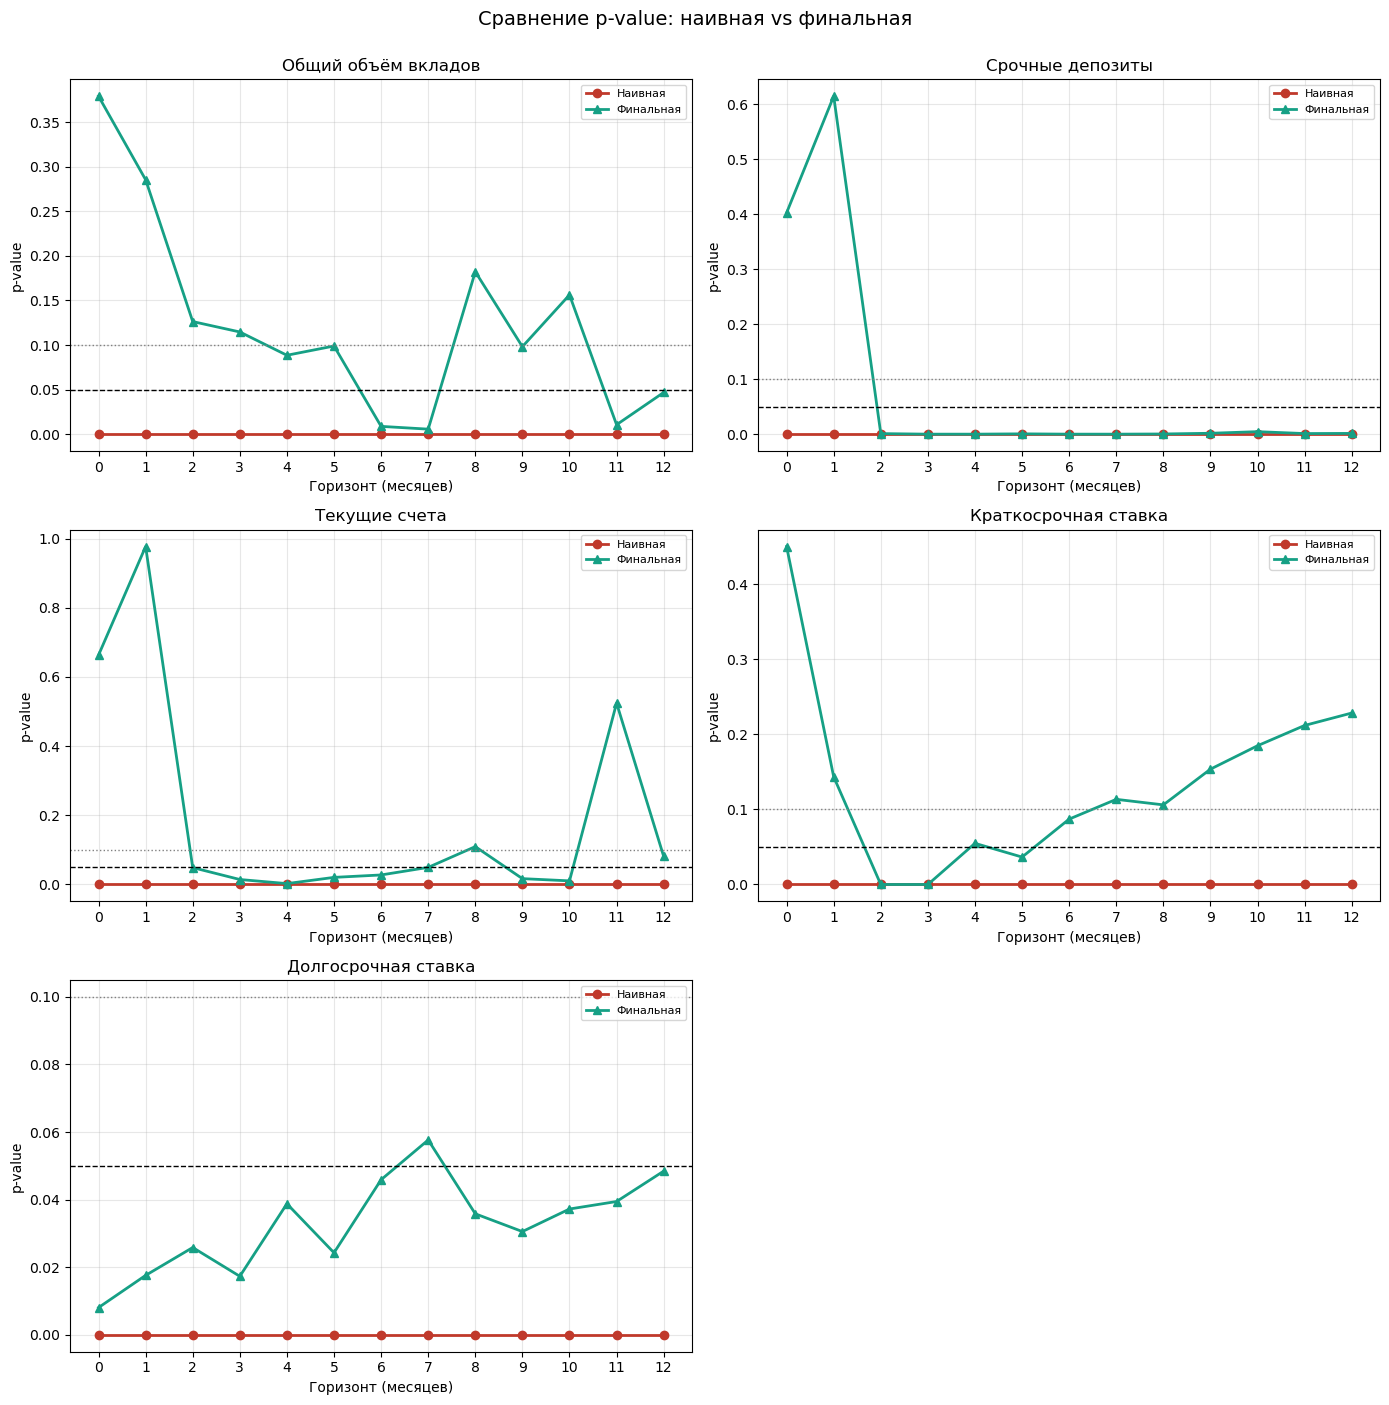

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Сравнение p-value: наивная vs финальная', 
             fontsize=14, y=1.00)

specs_list = [
    (specs_total, 'Общий объём вкладов', axes[0, 0]),
    (specs_td, 'Срочные депозиты', axes[0, 1]),
    (specs_ca, 'Текущие счета', axes[1, 0]),
    (specs_short, 'Краткосрочная ставка', axes[1, 1]),
    (specs_long, 'Долгосрочная ставка', axes[2, 0]),
]

for specs, title, ax in specs_list:
    h_range = list(range(0, 13))
    p_naive = [specs['naive'][h].pvalues['key_rate'] for h in h_range]
    p_final = [specs['final'][h].pvalues['key_rate'] for h in h_range]
    
    ax.plot(h_range, p_naive, marker='o', linewidth=2,
            label='Наивная', color='#c0392b')
    ax.plot(h_range, p_final, marker='^', linewidth=2,
            label='Финальная', color='#16a085')
    
    ax.axhline(0.05, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.10, color='grey', linestyle=':', linewidth=1)
    
    ax.set_title(title)
    ax.set_xlabel('Горизонт (месяцев)')
    ax.set_ylabel('p-value')
    ax.set_xticks(h_range)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[2, 1].axis('off')

plt.tight_layout()
plt.savefig('specification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по графику сравнения спецификаций

**Наивная модель** (красная) — p = 0.000 на всех горизонтах для всех переменных: ложная значимость из-за персистентности `key_rate` и трендовости объёмных рядов.
**Финальная модель** (зелёная) даёт принципиально другую картину:
  - **Общий объём вкладов** — значим только на h=6–7 и h=11 (p < 0.05); на остальных горизонтах p колеблется у 0.05–0.4, эффект неустойчив.
  - **Срочные депозиты** — резкий скачок значимости после h=2: с h=2 и до h=12 p стабильно около 0. Самый чистый и устойчивый результат во всём вопросе.
  - **Текущие счета** — значимы на h=2–7 (p < 0.05), затем на h=8–10 значимость пропадает, на h=11 снова появляется. Пик эффекта на h=4.
  - **Краткосрочная ставка** — значима на h=2–3 (p около 0), дальше p растёт до 0.2. То есть передача в короткие депозиты работает быстро, но на длинных горизонтах эффект размывается.
  - **Долгосрочная ставка** — значима на всех горизонтах (p < 0.05, кроме h=7, где p примерно 0.058). Самая устойчивая связь.

**Главное:** контраст между наивной и финальной моделями — доказательство того, что без лаг-аугментации и тренда оценки были бы систематически завышены. Финальная модель даёт честную картину, где эффект есть, но он неодинаков по силе и горизонтам для разных исходов.

---
## Общий вывод по вопросу 2: влияние ключевой ставки на рынок вкладов физлиц

### Основные результаты (финальная модель)

**Механизм передачи подтверждён в три шага:**

1. **Ключевая ставка → ставки по вкладам.** Краткосрочная ставка реагирует через 2–3 месяца с передачей близкой к полной (коэф около 1.0). Долгосрочная реагирует медленнее — коэф достигает 0.9 только к h=9–12.

2. **Ставки по вкладам → перекладывание средств.** Срочные депозиты растут начиная с h=2, эффект монотонно нарастает до h=15 без затухания (около 942 млрд руб. на h=15). Текущие счета падают на h=2–7 с пиком на h=4 (−255 млрд руб.) — люди переносят деньги на срочные вклады.

3. **Итоговый эффект на общий объём.** Значим на h=6–7 и h=11–15, на остальных горизонтах пограничный. Разница между ростом срочных депозитов и падением текущих счетов (около 225 млрд на h=4) указывает на приток новых денег в банковскую систему сверх простого перекладывания.

### Что показала наивная модель

Наивная LP без лаг-аугментации давала p = 0.000 на всех горизонтах с коэффициентами на порядок выше реальных. Это артефакт персистентности: `key_rate` (p = 0.955) и `total_funds_of_ind` (ρ > 1.0) движутся вместе просто потому что оба растут во времени. Лаг-аугментация и тренд убирают этот артефакт.

### Ограничения

- **Эндогенность ставки:** ЦБ повышает ставку в ответ на инфляцию, инфляция сама влияет на поведение вкладчиков. Полностью решить без инструментальных переменных невозможно.
- **Отсутствие контроля за экономическим циклом:** М2 исключён так как `total_funds_of_ind` является его компонентом. Реальный ВВП и промышленное производство доступны только поквартально.
- **Доходы населения:** не включены из-за отсутствия помесячных данных.

---
## Об идентификации причинно-следственной связи

### Что удалось установить

Анализ построен на методе Local Projections (Jorda 2005) с лаг-аугментацией
(Montiel Olea & Plagborg-Moller 2021). Результаты показывают устойчивую
условную корреляцию между ключевой ставкой и рынком вкладов: повышение ставки
на 1 п.п. ассоциируется с ростом срочных депозитов начиная с h=2 и падением
текущих счетов на h=2–7, что согласуется с механизмом перекладывания средств.

Это **условная корреляция**, а не строгий причинный эффект. Ставка эндогенна:
ЦБ повышает её в ответ на инфляцию, а инфляция сама влияет на поведение
вкладчиков. Без инструментальных переменных или естественного эксперимента
разделить эти эффекты невозможно. Это ограничение LP-анализа.

### Почему event study не подходит для этих данных

Альтернативный подход — event study на изменениях ставки — был рассмотрен и
отклонён по трём причинам.

**1. Шоков слишком мало.** Event study работает когда шоков много — десятки
изолированных событий по которым можно усреднить эффект. В данных 2013–2025
только два действительно резких шока: декабрь 2014 и февраль 2022.

**2. Ключевая ставка — не «событие», а персистентный ряд.** Event study
предполагает резкое одномоментное изменение на фоне стабильного тренда.
Ключевая ставка в России (p около 0.955) часто меняется серией последовательных
шагов (2014–2015, 2022, 2023–2024), и «фон» вокруг каждого изменения сам по
себе находится в движении. Предпосылка о стабильном контрфактическом тренде (то есть 
гипотетический сценарий, где экономика развивается без данного шага ЦБ, не является стабильным, 
так как на него продолжают влиять прошлые изменения ставки)
не выполняется — pre-тренд до шока уже содержит движение ставки.

**3. Малый T и высокая сезонность.** При 156 наблюдениях и окне +-3 месяца
каждое событие даёт только 7 точек. Сезонность за такое окно не отфильтровать,
и одно событие начинает доминировать над всей оценкой. Окно +-12 необходимое
для надёжного event study перекрывается соседними изменениями ставки.

### Итог

Полученные результаты следует интерпретировать как **информативную условную
корреляцию**: ставка и вклады движутся вместе в предсказуемом направлении
после контроля на персистентность, тренд и структурные шоки. Это согласуется
с теоретическим механизмом передачи денежно-кредитной политики, но не
является его строгим доказательством. Для идентификации причинно-следственной
связи потребовались бы инструментальные переменные или межстрановые панельные
данные с вариацией в денежно кредитной политике.

---

# Вопрос 3: Асимметрия эффекта ключевой ставки

Проверяем реагирует ли рынок вкладов по-разному на повышение и понижение ставки.

**Три группы наблюдений:**
- **Пауза** (hike=0, cut=0) — ставка не изменилась, базовая группа (93 месяца)
- **Повышение** (hike=1) — ставка выросла относительно прошлого месяца (23 месяца)
- **Понижение** (cut=1) — ставка снизилась относительно прошлого месяца (39 месяцев)

**Модель:**

- B1 — эффект ставки в паузу (база)
- B1 + B_rh — эффект ставки при повышении
- B1 + B_rc — эффект ставки при понижении
- B_rh — отличие повышения от паузы
- B_rc — отличие понижения от паузы
- B_rh − B_rc — прямой тест асимметрии повышение vs понижение

**Ограничение:** повышений только 23 наблюдения — оценки для группы повышений
менее надёжны чем для понижений. Результаты интерпретируются описательно.

In [92]:
df_q2['rate_change'] = df_q2['key_rate'].diff()
df_q2['hike'] = (df_q2['rate_change'] > 0).astype(int)
df_q2['cut'] = (df_q2['rate_change'] < 0).astype(int)

df_q2['rate_x_hike'] = df_q2['key_rate'] * df_q2['hike']
df_q2['rate_x_cut'] = df_q2['key_rate'] * df_q2['cut']

print(f"Пауз: {((df_q2['hike']==0) & (df_q2['cut']==0)).sum()}")
print(f"Повышений: {df_q2['hike'].sum()}")
print(f"Понижений: {df_q2['cut'].sum()}")

print("\nСредний месячный прирост объёма вкладов по группам:")
df_q2['direction'] = 'пауза'
df_q2.loc[df_q2['hike']==1, 'direction'] = 'повышение'
df_q2.loc[df_q2['cut']==1, 'direction'] = 'понижение'
print(df_q2.groupby('direction')['total_funds_of_ind'].apply(
    lambda x: x.diff().mean()).round(1))

Пауз: 94
Повышений: 23
Понижений: 39

Средний месячный прирост объёма вкладов по группам:
direction
пауза         553.1
повышение    1595.4
понижение    1256.3
Name: total_funds_of_ind, dtype: float64


In [87]:
def run_lp_asymmetry(df, y_col, max_h=15):
    df_work = df.copy()
    df_work['y_lag1'] = df_work[y_col].shift(1)

    controls = ['key_rate_lag1', 'y_lag1', 'trend',
                'month', 'shock_2014', 'shock_2022',
                'hike', 'cut', 'rate_x_hike', 'rate_x_cut']

    results = {}
    for h in range(0, max_h + 1):
        df_work[f'y_h{h}'] = df_work[y_col].shift(-h)
        df_model = df_work[['key_rate'] + controls + [f'y_h{h}']].dropna()
        X = sm.add_constant(df_model[['key_rate'] + controls])
        y = df_model[f'y_h{h}']
        results[h] = sm.OLS(y, X).fit(cov_type='HC3')

    return results


def print_asymmetry_results(results, title, max_h=15):
    def stars(p):
        if p < 0.01: return '***'
        if p < 0.05: return '** '
        if p < 0.10: return '*  '
        return '   '

    print(f"\n{title}")
    print("-" * 80)
    print(f"{'h':>3}  {'B1 пауза':>12}"
          f"{'B1+B_rh повыш':>22}"
          f"{'B1+B_rc пониж':>18}"
          f"{'B_rh−B_rc асимм':>22}")
    print("-" * 80)

    for h in range(0, max_h + 1):
        b1 = results[h].params['key_rate']
        bxh = results[h].params['rate_x_hike']
        bxc = results[h].params['rate_x_cut']
        p1 = results[h].pvalues['key_rate']

        hyp_hike = results[h].f_test('key_rate + rate_x_hike = 0')
        p_hike = hyp_hike.pvalue

        hyp_cut = results[h].f_test('key_rate + rate_x_cut = 0')
        p_cut = hyp_cut.pvalue

        hyp_asym = results[h].f_test('rate_x_hike - rate_x_cut = 0')
        p_asym = hyp_asym.pvalue

        print(f"{h:>3}  {b1:>10.1f}{stars(p1)}  "
              f"{b1+bxh:>14.1f}{stars(p_hike)}  "
              f"{b1+bxc:>14.1f}{stars(p_cut)}  "
              f"{bxh-bxc:>15.1f}{stars(p_asym)}")

In [93]:
def plot_asymmetry(results, title, max_h=15,
                   ylabel='Изменение объёма, млрд руб.'):
    horizons = list(range(0, max_h + 1))

    # Пауза — B1
    coefs_pause = [results[h].params['key_rate'] for h in horizons]
    ci_low_p = [results[h].conf_int().loc['key_rate', 0] for h in horizons]
    ci_high_p = [results[h].conf_int().loc['key_rate', 1] for h in horizons]

    # Повышение — B1 + B_rh
    coefs_hike, ci_low_h, ci_high_h = [], [], []
    for h in horizons:
        b = results[h].params['key_rate'] + results[h].params['rate_x_hike']
        coefs_hike.append(b)
        idx = list(results[h].params.index)
        r = np.zeros(len(idx))
        r[idx.index('key_rate')] = 1
        r[idx.index('rate_x_hike')] = 1
        se = np.sqrt(r @ results[h].cov_HC3 @ r)
        ci_low_h.append(b - 1.96 * se)
        ci_high_h.append(b + 1.96 * se)

    # Понижение —  B1 + B_rc
    coefs_cut, ci_low_c, ci_high_c = [], [], []
    for h in horizons:
        b = results[h].params['key_rate'] + results[h].params['rate_x_cut']
        coefs_cut.append(b)
        idx = list(results[h].params.index)
        r = np.zeros(len(idx))
        r[idx.index('key_rate')] = 1
        r[idx.index('rate_x_cut')] = 1
        se = np.sqrt(r @ results[h].cov_HC3 @ r)
        ci_low_c.append(b - 1.96 * se)
        ci_high_c.append(b + 1.96 * se)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(horizons, coefs_hike, color='#c0392b', linewidth=2,
            marker='o', markersize=5, label='Повышение ставки')
    ax.fill_between(horizons, ci_low_h, ci_high_h,
                    alpha=0.15, color='#c0392b')

    ax.plot(horizons, coefs_cut, color='#2c5f8a', linewidth=2,
            marker='o', markersize=5, label='Понижение ставки')
    ax.fill_between(horizons, ci_low_c, ci_high_c,
                    alpha=0.15, color='#2c5f8a')

    ax.plot(horizons, coefs_pause, color='#7f8c8d', linewidth=1.5,
            marker='o', markersize=4, linestyle='--', label='Пауза (база)')
    ax.fill_between(horizons, ci_low_p, ci_high_p,
                    alpha=0.10, color='#7f8c8d')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    for h in horizons:
        if results[h].f_test(
                'key_rate + rate_x_hike = 0').pvalue < 0.05:
            ax.scatter(h, coefs_hike[h], color='black', zorder=5, s=20)
        if results[h].f_test(
                'key_rate + rate_x_cut = 0').pvalue < 0.05:
            ax.scatter(h, coefs_cut[h], color='black', zorder=5, s=20)
        if results[h].pvalues['key_rate'] < 0.05:
            ax.scatter(h, coefs_pause[h], color='black', zorder=5, s=20)

    sig_marker = Line2D([0], [0], marker='o', color='w',
                        markerfacecolor='black', markersize=8,
                        label='Значимо на уровне 5%')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [sig_marker], loc='upper left')

    ax.set_xlabel('Горизонт (месяцев после изменения ставки)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(horizons)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

### Модель 1: Общий объём вкладов


Общий объём вкладов физлиц
--------------------------------------------------------------------------------
  h      B1 пауза         B1+B_rh повыш     B1+B_rc пониж       B_rh−B_rc асимм
--------------------------------------------------------------------------------
  0       -23.5               -0.7              -61.4                60.7   
  1        10.5               17.7                6.8                10.8   
  2        82.4               75.9               41.9                34.0   
  3        -2.5              120.8              -30.4               151.1   
  4       -86.5               85.4             -114.4               199.7** 
  5        36.5              168.4               30.8               137.7*  
  6        22.3              215.1**             13.2               201.9*  
  7        97.7              290.7**            170.0               120.7   
  8       -63.8              174.0              -21.0               195.0   
  9        42.3              249.2   

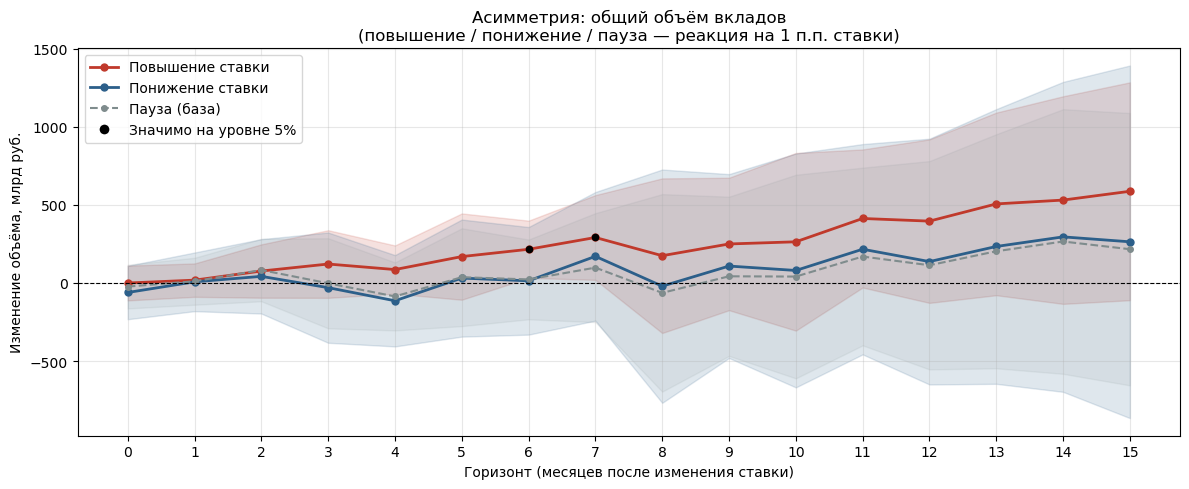

In [89]:
results_asym_total = run_lp_asymmetry(
    df_q2, 'total_funds_of_ind', max_h=15)
print_asymmetry_results(
    results_asym_total, "Общий объём вкладов физлиц")

fig = plot_asymmetry(
    results_asym_total,
    'Асимметрия: общий объём вкладов\n'
    '(повышение / понижение / пауза — реакция на 1 п.п. ставки)')
plt.savefig('asymmetry_total.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по модели 1: общий объём вкладов

**В паузу (B1):** эффект незначим ни на одном горизонте — когда ставка стоит
на месте, её уровень не влияет на объём вкладов.

**При повышении (B1+B_rh):** значимый эффект только на h=6–7 (215–291 млрд руб.).
На остальных горизонтах незначимо.

**При понижении (B1+B_rc):** эффект незначим ни на одном горизонте —
при снижении ставки объём вкладов не реагирует значимо.

**Тест асимметрии (B_rh−B_rc):** значим только на h=4 (200 млрд руб.) —
единственная точка где повышение вызывает значимо более сильную реакцию
чем понижение. На остальных горизонтах разница статистически неотличима
от нуля несмотря на большие коэффициенты — широкие доверительные интервалы
из-за малого числа повышений (23 месяца).

**Вывод:** очень слабое свидетельство асимметрии — только одна значимая
точка на h=4. Устойчивого паттерна нет.

### Модель 2: Срочные депозиты


Срочные депозиты
--------------------------------------------------------------------------------
  h      B1 пауза         B1+B_rh повыш     B1+B_rc пониж       B_rh−B_rc асимм
--------------------------------------------------------------------------------
  0       -16.6               16.1               -9.9                26.0   
  1        -2.2               27.0               -6.5                33.5   
  2       262.1              308.8**            256.3                52.5   
  3       257.9***           372.5***           255.4**             117.1*  
  4       235.5***           391.6***           262.7**             128.9*  
  5       262.8**            415.3***           327.5**              87.8   
  6       317.8***           466.2***           387.0***             79.2   
  7       340.7**            476.0***           456.9***             19.1   
  8       295.5              434.6***           419.9*               14.7   
  9       364.8              475.3**           

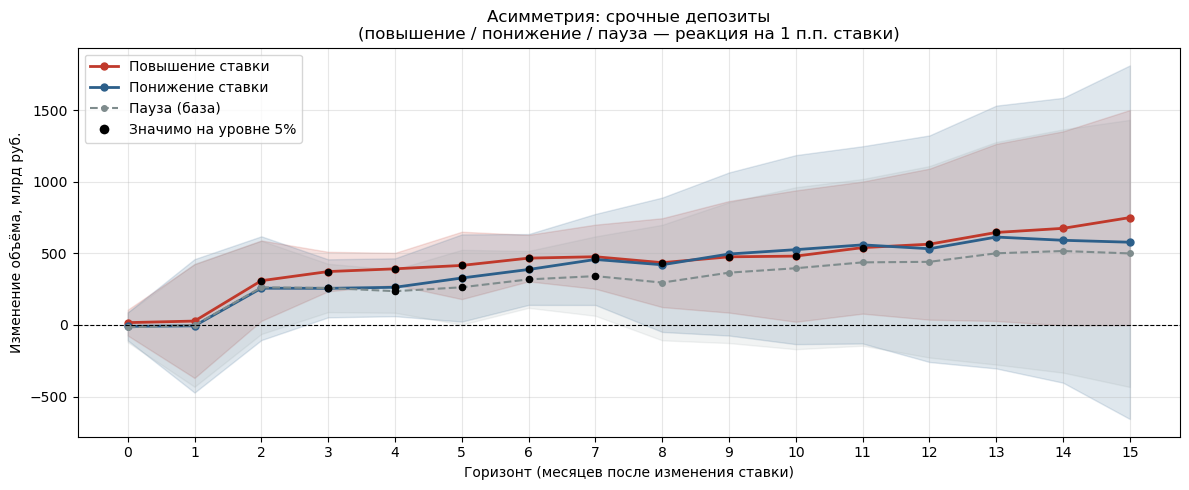

In [90]:
results_asym_td = run_lp_asymmetry(
    df_q2, 'time_deposits_of_ind', max_h=15)
print_asymmetry_results(
    results_asym_td, "Срочные депозиты")

fig = plot_asymmetry(
    results_asym_td,
    'Асимметрия: срочные депозиты\n'
    '(повышение / понижение / пауза — реакция на 1 п.п. ставки)')
plt.savefig('asymmetry_td.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по модели 2: срочные депозиты

**В паузу (B1):** эффект значим на h=3–7 (236–341 млрд руб.) — когда ставка
держится на одном уровне достаточно долго, люди постепенно открывают срочные
депозиты реагируя на текущий уровень.

**При повышении (B1+B_rh):** эффект значим с h=2 до h=13 (309–646 млрд руб.) —
устойчивый и сильный приток на большинстве горизонтах.

**При понижении (B1+B_rc):** эффект значим на h=3–7 (255–457 млрд руб.) —
подтверждается эффект «зафиксировать ставку до снижения»: при понижении
люди торопятся открыть вклады пока банки ещё не снизили депозитные ставки.

**Тест асимметрии (B_rh−B_rc):** незначим ни на одном горизонте на уровне 5% —
повышение и понижение вызывают статистически неразличимую реакцию
срочных депозитов.

**Вывод:** рынок срочных депозитов симметричен — оба направления изменения
ставки вызывают значимый приток сопоставимой величины. Асимметрии нет.

### Модель 3: Текущие счета


Текущие счета
--------------------------------------------------------------------------------
  h      B1 пауза         B1+B_rh повыш     B1+B_rc пониж       B_rh−B_rc асимм
--------------------------------------------------------------------------------
  0        21.3                4.1               -1.7                 5.8   
  1        48.9               18.0               76.3               -58.3   
  2      -132.8             -197.6             -138.5               -59.1   
  3      -180.2             -191.5             -159.0               -32.5   
  4      -215.7*            -224.7**           -205.5               -19.2   
  5       -88.4             -141.6              -78.9               -62.7   
  6      -142.6             -135.0             -135.7                 0.7   
  7       -87.2              -68.8              -56.8               -12.1   
  8      -158.1             -107.7             -136.2                28.4   
  9      -136.6              -84.1             -11

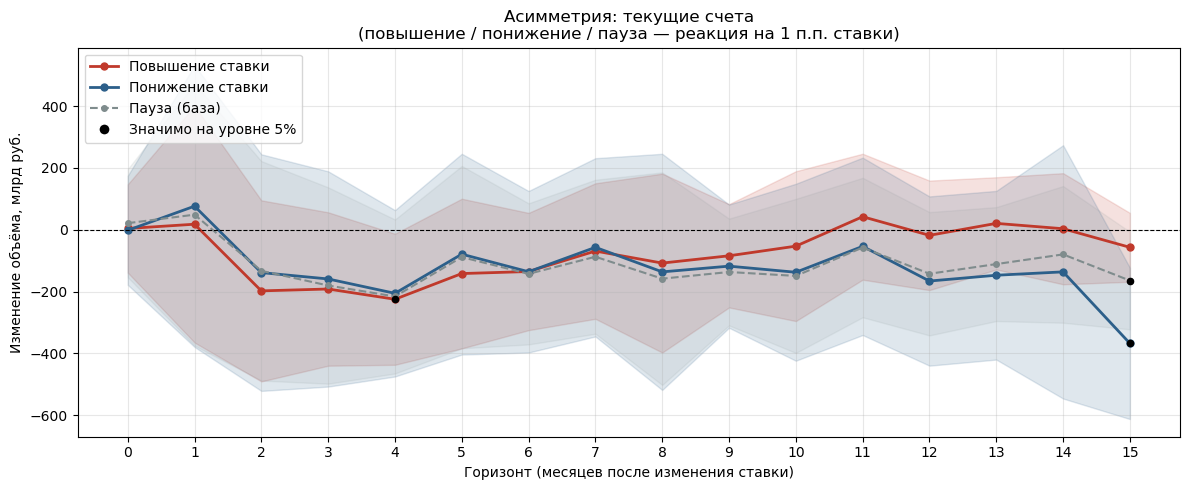

In [91]:
results_asym_ca = run_lp_asymmetry(
    df_q2, 'curr_accounts_of_ind', max_h=15)
print_asymmetry_results(
    results_asym_ca, "Текущие счета")

fig = plot_asymmetry(
    results_asym_ca,
    'Асимметрия: текущие счета\n'
    '(повышение / понижение / пауза — реакция на 1 п.п. ставки)')
plt.savefig('asymmetry_ca.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по модели 3: текущие счета

**В паузу (B1):** эффект значим только на h=15 (−164 млрд руб.) — в целом
текущие счета не реагируют на уровень ставки когда та стоит на месте.

**При повышении (B1+B_rh):** значимый эффект только на h=4 (−225 млрд руб.) —
слабая реакция, на большинстве горизонтов незначимо.

**При понижении (B1+B_rc):** значимый отрицательный эффект только на h=15
(−367 млрд руб.) — при снижении ставки текущие счета падают на длинном
горизонте. Вероятно смешение с экономическим контекстом: понижения ставки
совпадали с посткризисными периодами когда люди тратили накопления.

**Тест асимметрии (B_rh−B_rc):** значим на h=15 (311 млрд руб.) — при
понижении текущие счета падают значимо сильнее чем при повышении. Одна
значимая точка на крайнем горизонте при малом числе повышений
интерпретируется с осторожностью.

**Вывод:** текущие счета реагируют слабо и несистемно. Единственный
устойчивый результат — значимое падение при понижении ставки на h=15,
что скорее всего отражает экономический контекст а не поведенческую асимметрию.

## Итоговый вывод по вопросу 3: асимметрия эффекта ключевой ставки

### Основной результат

Гипотеза об асимметрии в целом **не подтверждается** на уровне значимости 5%.

**Общий объём вкладов:** единственная значимая точка теста асимметрии на h=4.
Устойчивого паттерна нет — при повышении эффект значим на h=6–7, при
понижении незначим нигде, но разница между ними формально значима только
в одной точке.

**Срочные депозиты:** асимметрии нет. Оба направления вызывают значимый
приток сопоставимой величины — при повышении с h=2, при понижении с h=3.
Тест асимметрии незначим ни на одном горизонте. Ключевая находка —
эффект «фиксации ставки» при понижении (h=3–7): люди открывают вклады
пока банки ещё не снизили депозитные ставки.

**Текущие счета:** значимая асимметрия только на h=15 — интерпретируется
с осторожностью, вероятно отражает экономический контекст посткризисных
периодов а не поведенческую асимметрию.

### Содержательная интерпретация

Наиболее интересный результат — не асимметрия а симметрия срочных
депозитов. Рынок реагирует на оба направления изменения ставки, но
через разные механизмы: при повышении люди открывают вклады чтобы
заработать больше, при понижении — чтобы зафиксировать выгодные условия
до их ухудшения. Итоговые эффекты сопоставимы.

### Ограничения

Повышений в выборке только 23 из 156 наблюдений — тесты для группы
повышений имеют низкую мощность и широкие доверительные интервалы.
Периоды повышений и понижений различаются по экономическому контексту —
разделить поведенческую асимметрию от контекстуальной без инструментальных
переменных невозможно.